<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [2]:
# Your code here
college = pd.read_csv('./data/college.csv')

#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [3]:
# Your code here
college.shape

(777, 19)

In [4]:
college.dtypes

Unnamed: 0         str
Private            str
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD                str
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object

In [5]:
college.isnull().sum()

Unnamed: 0     0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

In [6]:
college.columns

Index(['Unnamed: 0', 'Private', 'Apps', 'Accept', 'Enroll', 'Top10perc',
       'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board',
       'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni',
       'Expend', 'Grad.Rate'],
      dtype='str')

In [7]:
college.rename(columns={'Unnamed: 0': 'Uni'}, inplace=True)
college.head()

,Uni,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [8]:
# Your code here
college['PhD'] = pd.to_numeric(college['PhD'], errors='coerce')

In [9]:
college['PhD'] = college['PhD'].clip(upper=100)
college['PhD'] = college['PhD'].fillna(college['PhD'].median()) 

In [10]:
college['PhD']

0      70.0
1      29.0
2      53.0
3      92.0
4      76.0
       ... 
772    60.0
773    73.0
774    67.0
775    96.0
776    75.0
Name: PhD, Length: 777, dtype: float64

#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [11]:
# Your code here
college['Grad.Rate'] = college['Grad.Rate'].clip(upper=100)
college['Grad.Rate'] = college['Grad.Rate'].fillna(college['Grad.Rate'].median())

## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [40]:
%%writefile myutils.py
import pandas as pd
def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """

    output = []

    for col in df.select_dtypes(include='number').columns:

        data = df[col]
        value = data.skew()

       
        if -0.5 < value < 0.5:
            degree = "Approximately Symmetric"
        elif -1 < value <= -0.5 or 0.5 <= value < 1:
            degree = "Moderately Skewed"
        else:
            degree = "Highly Skewed"

        # Direction
        if value > 0:
            side = "Positive"
        elif value < 0:
            side = "Negative"
        else:
            side = "Symmetric"

        
        if -0.5 < value < 0.5:
            method = "None"

        elif data.min() == 0:
            method = "Log Plus One or Yeo-Johnson"

        elif data.min() > 0:
            method = "Box-Cox or Yeo-Johnson"

        else:
            method = "Yeo-Johnson"

        output.append({
            "Feature": col,
            "Skewness": value,
            "Degree": degree,
            "Direction": side,
            "Recommended Transformation": method})

    return pd.DataFrame(output)

Overwriting myutils.py


In [37]:
# Now import the function from myutils
from myutils import skew_calc

In [38]:
def plot_transformations(df, skew_table):

    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from sklearn.preprocessing import PowerTransformer

    """
    Applies the recommended transformation to each numeric column,
    then plots the original and transformed distributions side by side.
    """
    for row in range(len(skew_table)):

        feature = skew_table.loc[row, 'Feature']
        recommendation = skew_table.loc[row, 'Recommended Transformation']

        original = df[feature]

        
        if recommendation == 'None':
            transformed = original

        elif recommendation == 'Log, Box-Cox or Yeo-Johnson':
            transformed = np.log1p(original)

        elif recommendation == 'Box-Cox or Yeo-Johnson':

            if original.min() > 0:
                transformer = PowerTransformer(method='box-cox')
            else:
                transformer = PowerTransformer(method='yeo-johnson')

            transformed = transformer.fit_transform( original.values.reshape(-1, 1)).flatten()

        else:
            transformed = original

        fig, ax = plt.subplots(1, 2, figsize=(12, 4))

        original.plot.hist(
            ax=ax[0],
            bins=30,
            density=True,
            alpha=0.7)

        original.plot.kde(ax=ax[0])

        ax[0].set_title(
            f"Original {feature}\n"
            f"Skew: {round(original.skew(), 2)}")

        ax[0].set_xlabel(feature)

        transformed_series = pd.Series(transformed)

        transformed_series.plot.hist(
            ax=ax[1],
            bins=30,
            density=True,
            alpha=0.7)

        transformed_series.plot.kde(ax=ax[1])

        ax[1].set_title(
            f"Transformed {feature}\n"
            f"Method: {recommendation}\n"
            f"Skew: {round(transformed_series.skew(), 2)}")

        ax[1].set_xlabel(feature)

        plt.tight_layout()
        plt.show()

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [39]:
# Your code here
skew_table = skew_calc(college)
skew_table

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Approximately Symmetric,Positive,None needed
5,F.Undergrad,2.610458,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Positive,Box-Cox or Yeo-Johnson
8,Room.Board,0.477356,Approximately Symmetric,Positive,None needed
9,Books,3.485025,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


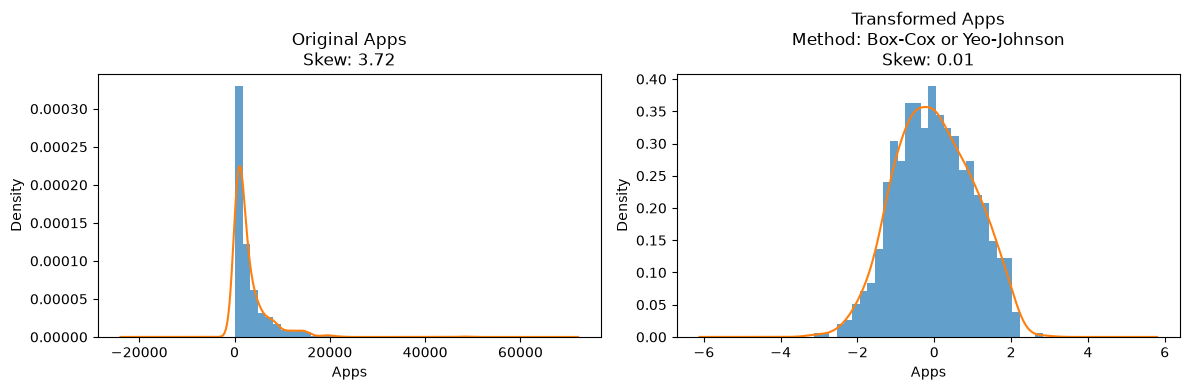

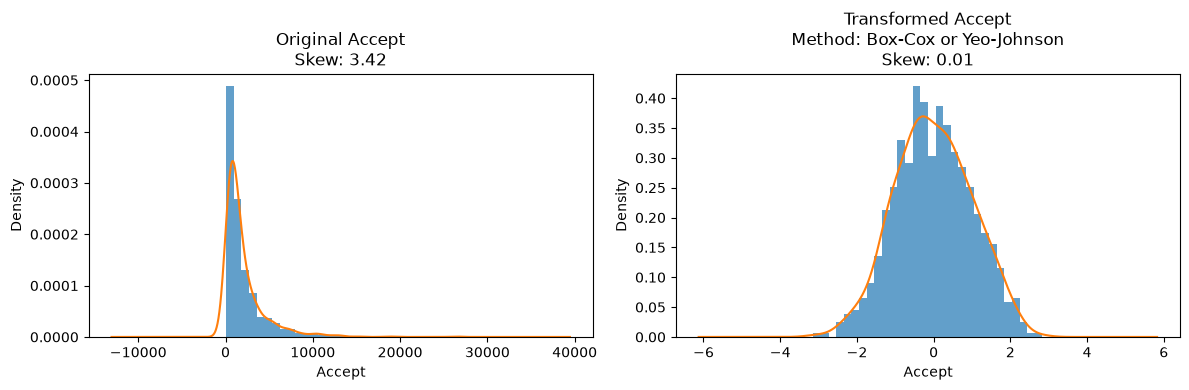

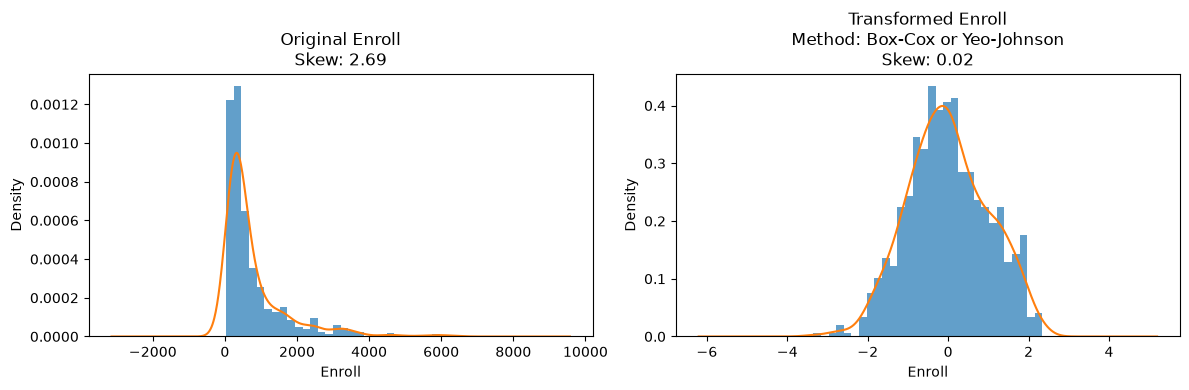

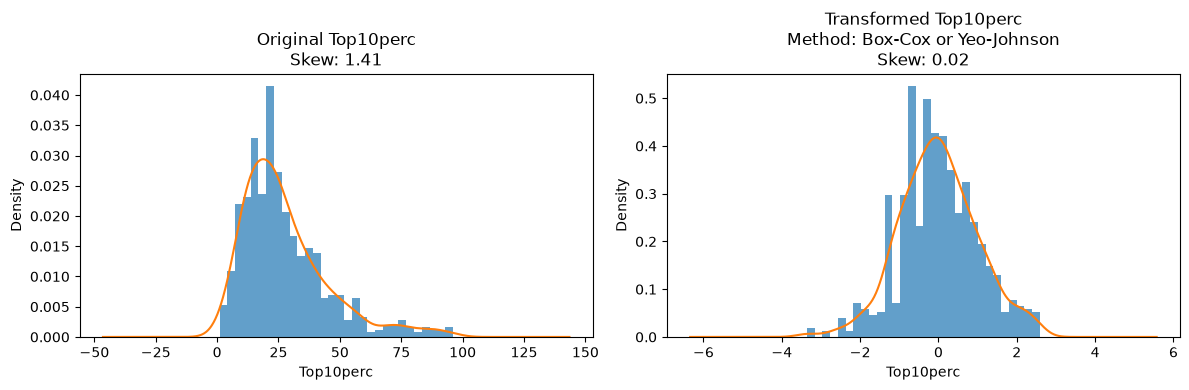

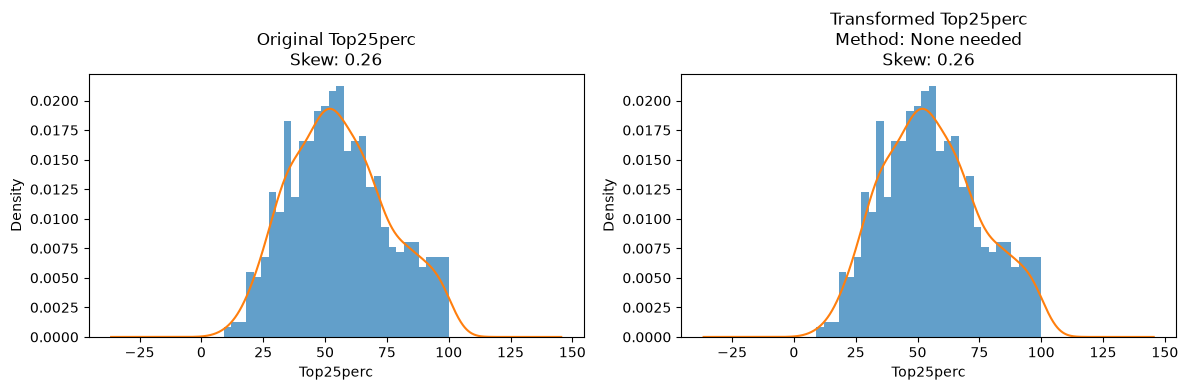

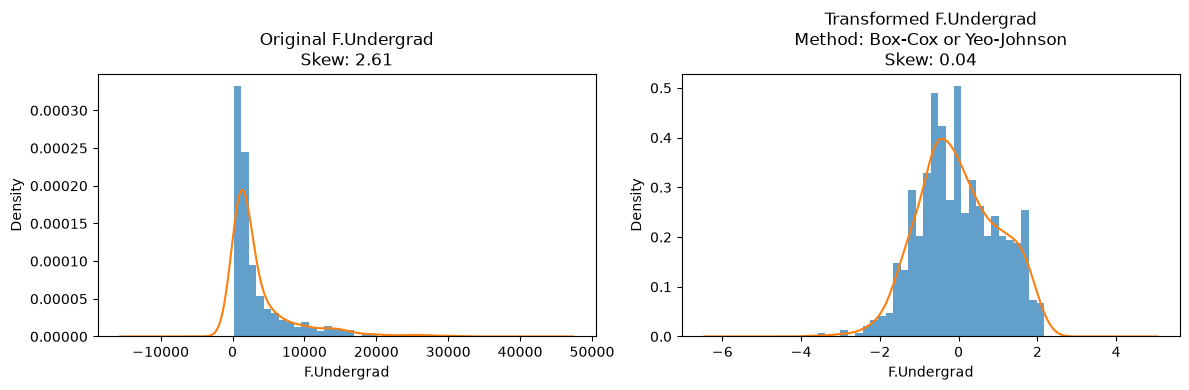

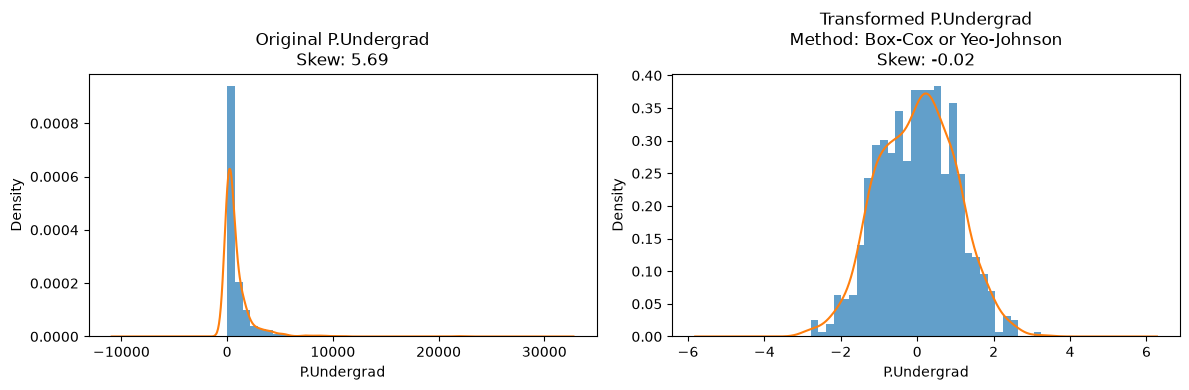

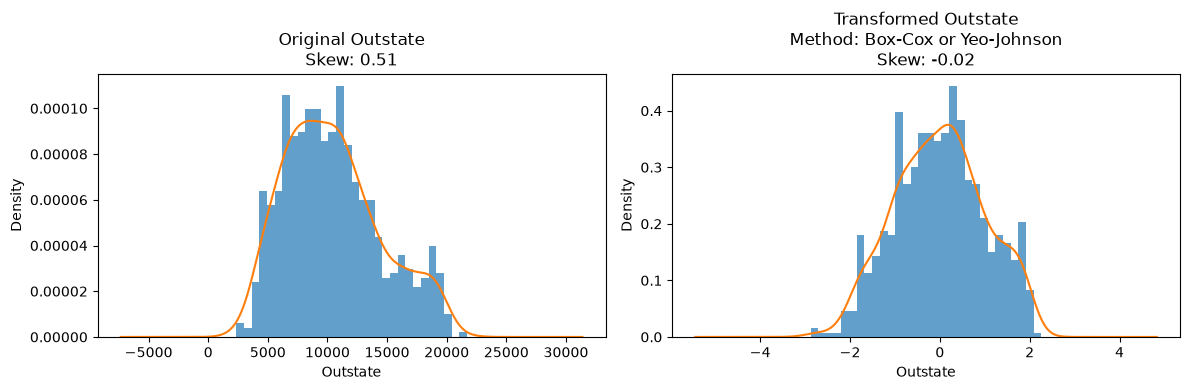

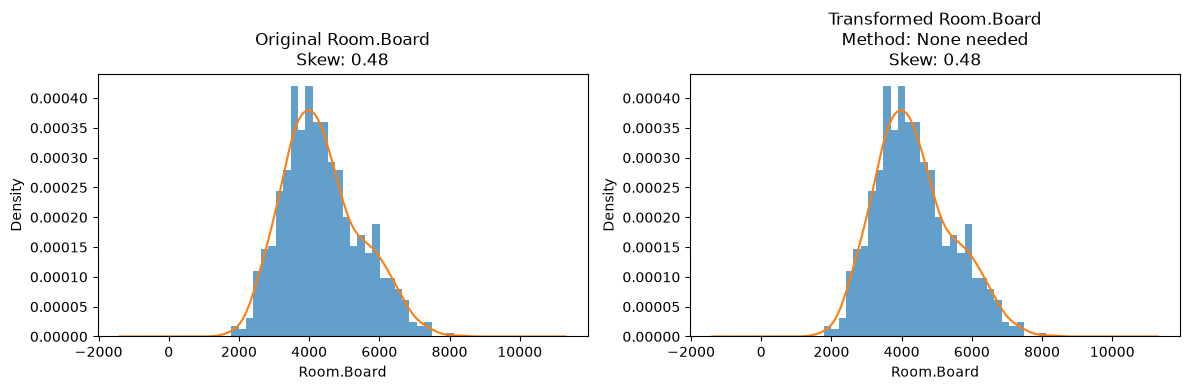

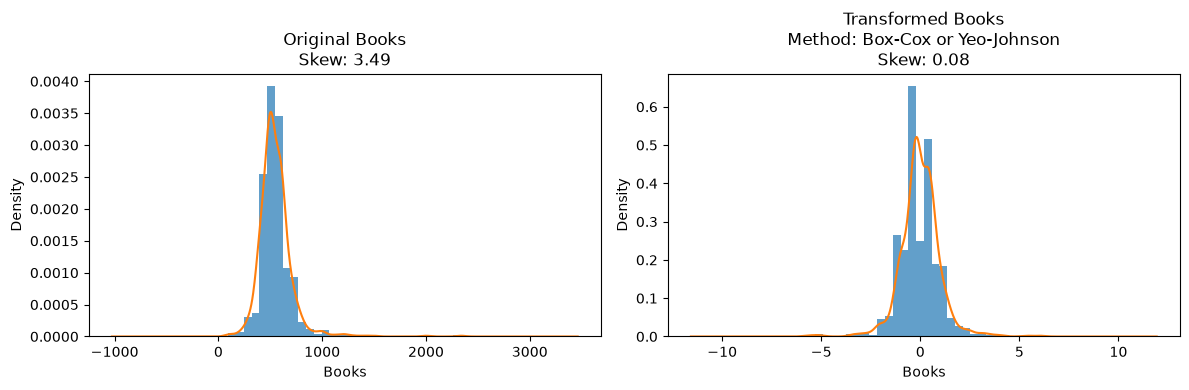

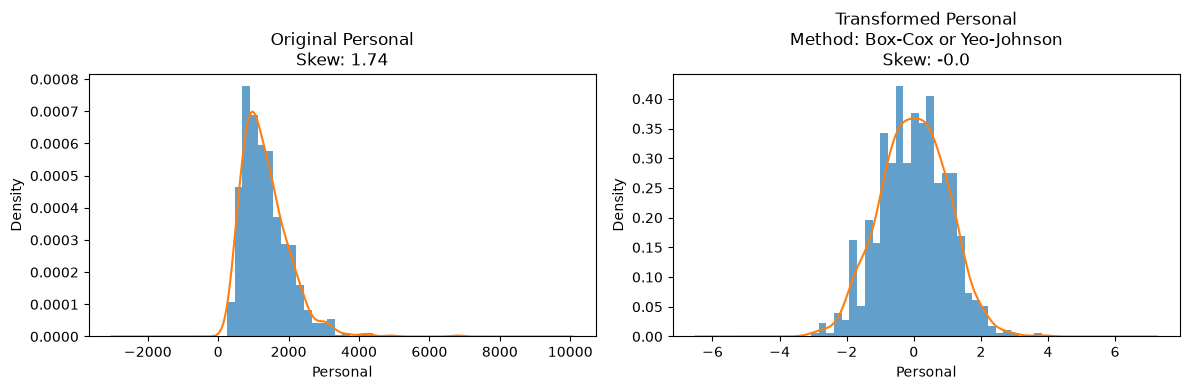

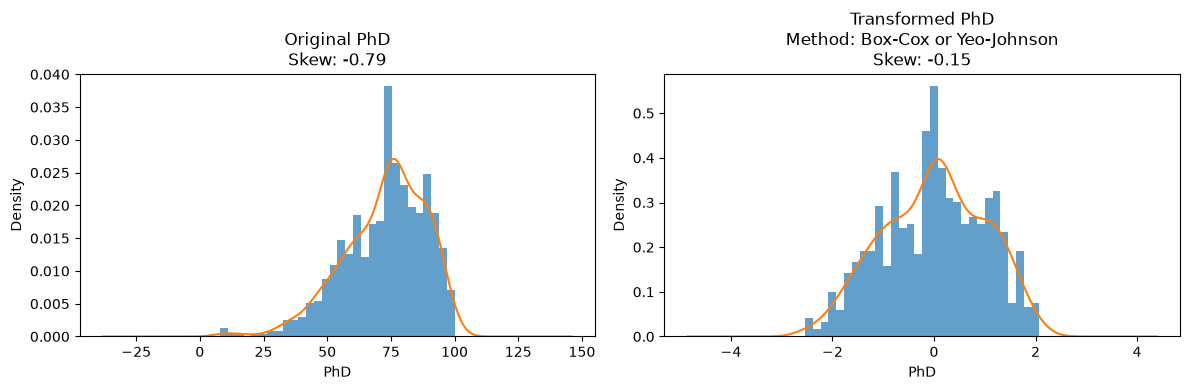

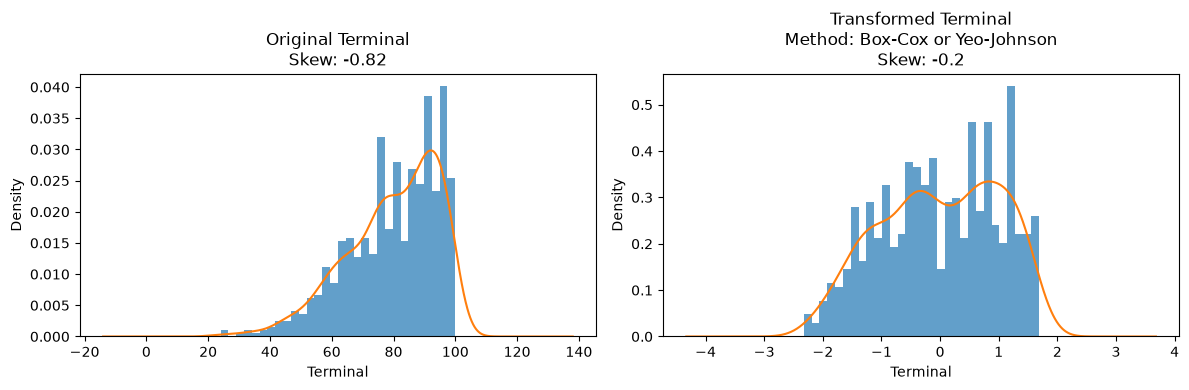

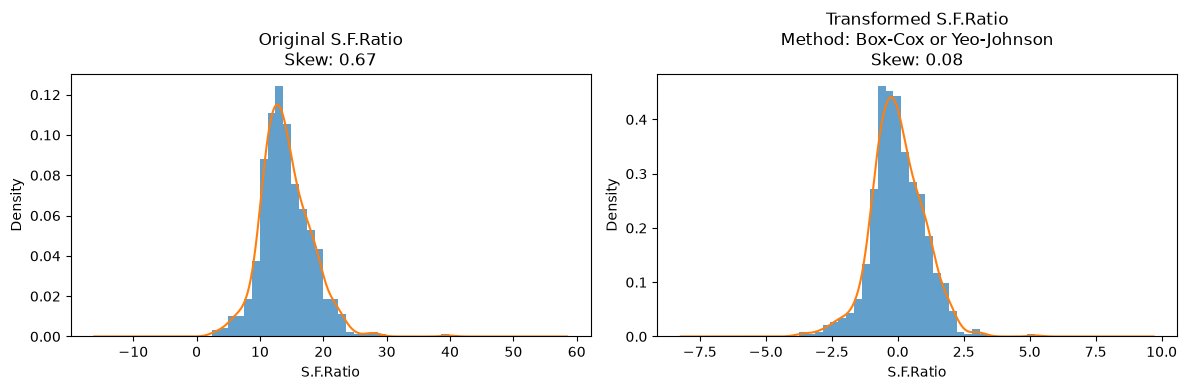

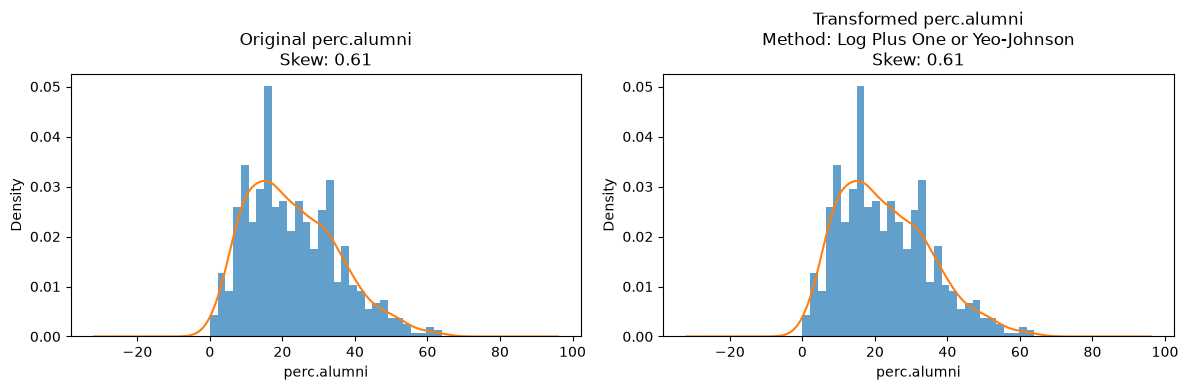

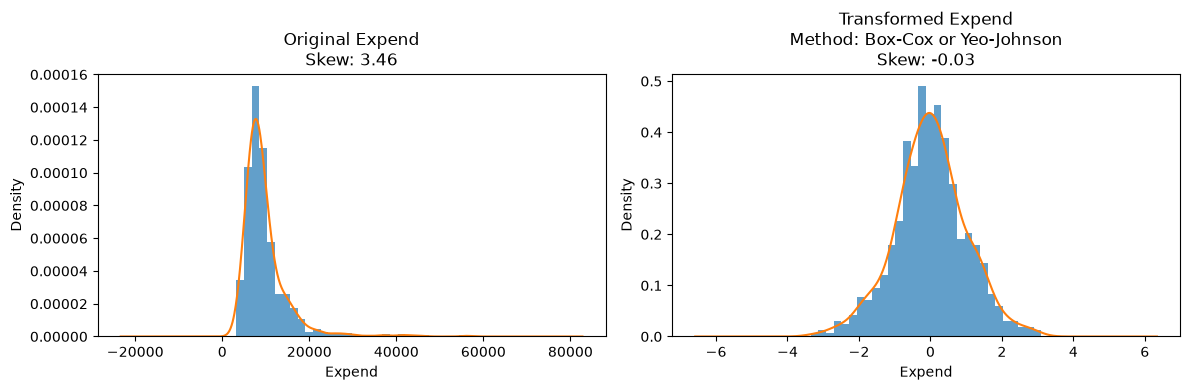

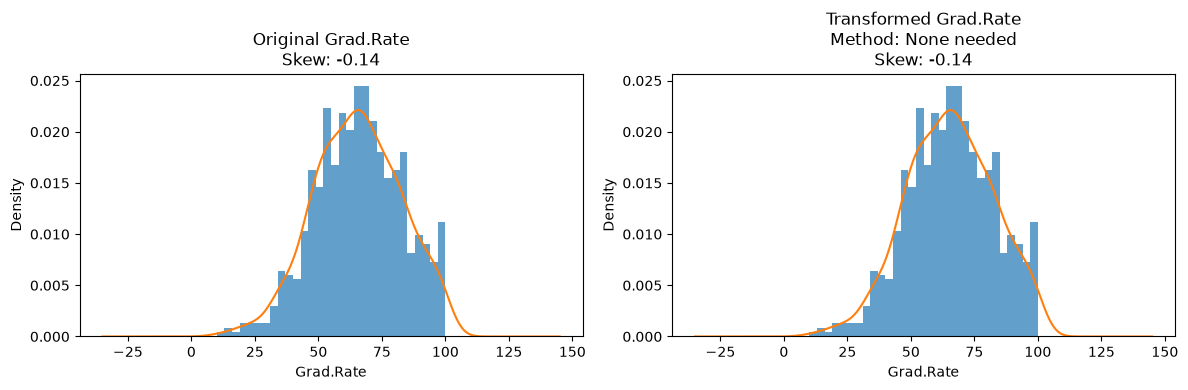

In [41]:
# Your code here
plot_transformations(college, skew_table)

In [ ]:
# Your code here


In [ ]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [42]:
from sklearn.preprocessing import PowerTransformer
import numpy as np

trans_cols = []

for i in range(len(skew_table)):

    feature = skew_table.loc[i, 'Feature']
    recommendation = skew_table.loc[i, 'Recommended Transformation']

    if recommendation == "None":
        continue
    elif recommendation == "Log, Box-Cox or Yeo-Johnson":
        college[feature + "_transformed"] = np.log1p(college[feature])

    elif recommendation == "Box-Cox or Yeo-Johnson":

        if college[feature].min() > 0:
            pt = PowerTransformer(method="box-cox")
        else:
            pt = PowerTransformer(method="yeo-johnson")
        college[feature + "_transformed"] = pt.fit_transform(
            college[[feature]])

    trans_cols.append(feature + "_transformed")
# Your code here 

In [43]:
college

,Uni,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Top10perc_transformed,F.Undergrad_transformed,P.Undergrad_transformed,Outstate_transformed,Books_transformed,Personal_transformed,PhD_transformed,Terminal_transformed,S.F.Ratio_transformed,Expend_transformed
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,-0.053119,0.433599,0.300156,-0.693449,-0.614254,1.271398,-0.291316,-0.282374,1.017946,-0.491183
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,-0.584905,0.365382,0.868239,0.556268,1.302365,0.456551,-2.177859,-2.248129,-0.435083,0.552362
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,-0.120942,-0.636774,-0.727254,0.322011,-1.038575,-0.068655,-1.262773,-1.040711,-0.250216,0.096393
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,1.614476,-1.531207,-0.974032,0.703926,-0.614254,-0.651734,1.363504,1.364588,-1.741872,1.726997
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,-0.584905,-2.588901,0.625418,-0.656776,1.553608,0.456551,0.115517,-0.687052,-0.515571,0.637044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,...,-2.216819,0.496824,1.237428,-0.896884,-0.229195,-0.007652,-0.895214,-1.346018,1.662786,-1.979972
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,...,0.012544,0.421876,0.794930,0.384737,0.449601,0.076697,-0.092070,-0.491253,-0.146331,0.224801
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,...,0.577680,0.403276,-0.431206,-0.863470,0.555037,-0.879821,-0.482220,-0.491253,0.133265,-0.029381
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,...,2.570900,0.951592,-0.824813,1.971742,0.633970,1.186495,1.712560,1.263238,-2.381681,2.768809


In [44]:
college.info()

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Uni                      777 non-null    str    
 1   Private                  777 non-null    str    
 2   Apps                     777 non-null    int64  
 3   Accept                   777 non-null    int64  
 4   Enroll                   777 non-null    int64  
 5   Top10perc                777 non-null    int64  
 6   Top25perc                777 non-null    int64  
 7   F.Undergrad              777 non-null    int64  
 8   P.Undergrad              777 non-null    int64  
 9   Outstate                 777 non-null    int64  
 10  Room.Board               777 non-null    int64  
 11  Books                    777 non-null    int64  
 12  Personal                 777 non-null    int64  
 13  PhD                      777 non-null    float64
 14  Terminal                 777 non-null

In [45]:
college['PhD_transformed'] = college['PhD_transformed'].fillna(college['PhD_transformed'].median())

In [46]:
college['PhD_transformed'].isnull().sum()

np.int64(0)

## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [47]:
# Your code here 
college['Accept_Rate'] = college['Accept'] / college['Apps']

In [48]:
college

,Uni,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,F.Undergrad_transformed,P.Undergrad_transformed,Outstate_transformed,Books_transformed,Personal_transformed,PhD_transformed,Terminal_transformed,S.F.Ratio_transformed,Expend_transformed,Accept_Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,0.433599,0.300156,-0.693449,-0.614254,1.271398,-0.291316,-0.282374,1.017946,-0.491183,0.742169
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,0.365382,0.868239,0.556268,1.302365,0.456551,-2.177859,-2.248129,-0.435083,0.552362,0.880146
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,-0.636774,-0.727254,0.322011,-1.038575,-0.068655,-1.262773,-1.040711,-0.250216,0.096393,0.768207
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,-1.531207,-0.974032,0.703926,-0.614254,-0.651734,1.363504,1.364588,-1.741872,1.726997,0.836930
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,-2.588901,0.625418,-0.656776,1.553608,0.456551,0.115517,-0.687052,-0.515571,0.637044,0.756477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,...,0.496824,1.237428,-0.896884,-0.229195,-0.007652,-0.895214,-1.346018,1.662786,-1.979972,0.689577
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,...,0.421876,0.794930,0.384737,0.449601,0.076697,-0.092070,-0.491253,-0.146331,0.224801,0.921388
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,...,0.403276,-0.431206,-0.863470,0.555037,-0.879821,-0.482220,-0.491253,0.133265,-0.029381,0.913209
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,...,0.951592,-0.824813,1.971742,0.633970,1.186495,1.712560,1.263238,-2.381681,2.768809,0.229145


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [49]:
# Your code here 
college['Outstate_Tier'] = pd.cut(college['Outstate'],bins=3,labels=['Low', 'Medium', 'High'])

In [50]:
college

,Uni,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,P.Undergrad_transformed,Outstate_transformed,Books_transformed,Personal_transformed,PhD_transformed,Terminal_transformed,S.F.Ratio_transformed,Expend_transformed,Accept_Rate,Outstate_Tier
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,0.300156,-0.693449,-0.614254,1.271398,-0.291316,-0.282374,1.017946,-0.491183,0.742169,Low
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,0.868239,0.556268,1.302365,0.456551,-2.177859,-2.248129,-0.435083,0.552362,0.880146,Medium
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,-0.727254,0.322011,-1.038575,-0.068655,-1.262773,-1.040711,-0.250216,0.096393,0.768207,Medium
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,-0.974032,0.703926,-0.614254,-0.651734,1.363504,1.364588,-1.741872,1.726997,0.836930,Medium
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,0.625418,-0.656776,1.553608,0.456551,0.115517,-0.687052,-0.515571,0.637044,0.756477,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,...,1.237428,-0.896884,-0.229195,-0.007652,-0.895214,-1.346018,1.662786,-1.979972,0.689577,Low
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,...,0.794930,0.384737,0.449601,0.076697,-0.092070,-0.491253,-0.146331,0.224801,0.921388,Medium
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,...,-0.431206,-0.863470,0.555037,-0.879821,-0.482220,-0.491253,0.133265,-0.029381,0.913209,Low
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,...,-0.824813,1.971742,0.633970,1.186495,1.712560,1.263238,-2.381681,2.768809,0.229145,High


#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [51]:
college['Outstate_Tier_Encoded'] = college['Outstate_Tier'].map({'Low': 1,'Medium': 2,'High': 3})

In [52]:
college

,Uni,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Outstate_transformed,Books_transformed,Personal_transformed,PhD_transformed,Terminal_transformed,S.F.Ratio_transformed,Expend_transformed,Accept_Rate,Outstate_Tier,Outstate_Tier_Encoded
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,-0.693449,-0.614254,1.271398,-0.291316,-0.282374,1.017946,-0.491183,0.742169,Low,1
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,0.556268,1.302365,0.456551,-2.177859,-2.248129,-0.435083,0.552362,0.880146,Medium,2
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,0.322011,-1.038575,-0.068655,-1.262773,-1.040711,-0.250216,0.096393,0.768207,Medium,2
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,0.703926,-0.614254,-0.651734,1.363504,1.364588,-1.741872,1.726997,0.836930,Medium,2
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,-0.656776,1.553608,0.456551,0.115517,-0.687052,-0.515571,0.637044,0.756477,Low,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,...,-0.896884,-0.229195,-0.007652,-0.895214,-1.346018,1.662786,-1.979972,0.689577,Low,1
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,...,0.384737,0.449601,0.076697,-0.092070,-0.491253,-0.146331,0.224801,0.921388,Medium,2
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,...,-0.863470,0.555037,-0.879821,-0.482220,-0.491253,0.133265,-0.029381,0.913209,Low,1
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,...,1.971742,0.633970,1.186495,1.712560,1.263238,-2.381681,2.768809,0.229145,High,3


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [53]:
# Your code here 
college['Private_encoded'] = college['Private'].map({'Yes': 1, 'No': 0})

## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [55]:
cols_to_scale = []
scaler = StandardScaler()
# Your code here
trans_cols = [col for col in college.columns if col.endswith('_transformed')]
cols_to_scale = trans_cols + ['Outstate_Tier_Encoded', 'Private_encoded']

for col in cols_to_scale:
    college[col + '_scaled'] = scaler.fit_transform(college[[col]])

In [56]:
college

,Uni,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,P.Undergrad_transformed_scaled,Outstate_transformed_scaled,Books_transformed_scaled,Personal_transformed_scaled,PhD_transformed_scaled,Terminal_transformed_scaled,S.F.Ratio_transformed_scaled,Expend_transformed_scaled,Outstate_Tier_Encoded_scaled,Private_encoded_scaled
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,0.300156,-0.693449,-0.614254,1.271398,-0.291316,-0.282374,1.017946,-0.491183,-1.098797,0.612553
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,0.868239,0.556268,1.302365,0.456551,-2.177859,-2.248129,-0.435083,0.552362,0.358140,0.612553
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,-0.727254,0.322011,-1.038575,-0.068655,-1.262773,-1.040711,-0.250216,0.096393,0.358140,0.612553
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,-0.974032,0.703926,-0.614254,-0.651734,1.363504,1.364588,-1.741872,1.726997,0.358140,0.612553
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,0.625418,-0.656776,1.553608,0.456551,0.115517,-0.687052,-0.515571,0.637044,-1.098797,0.612553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,...,1.237428,-0.896884,-0.229195,-0.007652,-0.895214,-1.346018,1.662786,-1.979972,-1.098797,-1.632512
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,...,0.794930,0.384737,0.449601,0.076697,-0.092070,-0.491253,-0.146331,0.224801,0.358140,0.612553
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,...,-0.431206,-0.863470,0.555037,-0.879821,-0.482220,-0.491253,0.133265,-0.029381,-1.098797,0.612553
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,...,-0.824813,1.971742,0.633970,1.186495,1.712560,1.263238,-2.381681,2.768809,1.815078,0.612553


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

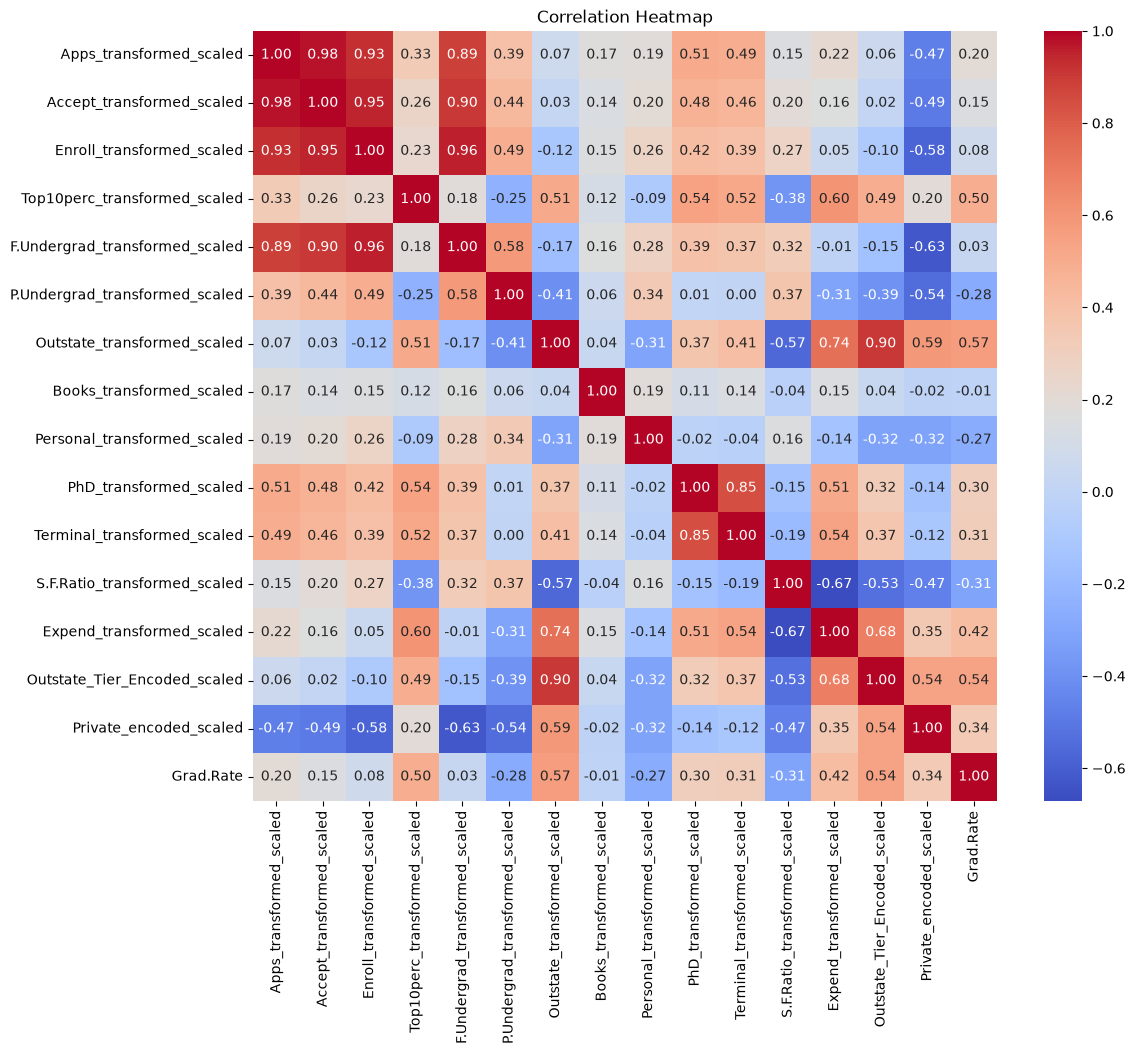

In [57]:
# Your code here 

scaled_cols = [col for col in college.columns if 'scaled' in col]
scaled_cols.append('Grad.Rate')

plt.figure(figsize=(12,10))
sns.heatmap(college[scaled_cols].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [59]:
college = college.drop(columns=['Accept_transformed_scaled', 'Enroll_transformed_scaled', 'F.Undergrad_transformed_scaled','Terminal_transformed_scaled','Outstate_Tier_Encoded_scaled'])

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [60]:
# Your code here 

y = college['Grad.Rate']
X_Un = college[
    ['Apps','Accept','Enroll','Top10perc','F.Undergrad',
     'P.Undergrad','Outstate','Books','Personal',
     'PhD','Terminal','S.F.Ratio','Expend',
     'Outstate_Tier_Encoded','Private_encoded']]

# Transformed features
scaled_cols = [col for col in college.columns if 'scaled' in col]
X_Tr = college[scaled_cols]

X_train_Un, X_test_Un, y_train_Un, y_test_Un = train_test_split(X_Un, y, test_size=0.3, random_state=42)
X_train_Tr, X_test_Tr, y_train_Tr, y_test_Tr = train_test_split(X_Tr, y, test_size=0.3, random_state=42)

#### 15. Fit a linear regression using the raw predictors


In [61]:
untrans_predictors = []

# Your code here 

lr_Un = LinearRegression()

lr_Un.fit(X_train_Un, y_train_Un)

print("Raw Train Score:", lr_Un.score(X_train_Un, y_train_Un))
print("Raw Test Score:", lr_Un.score(X_test_Un, y_test_Un))

Raw Train Score: 0.42454916709573765
Raw Test Score: 0.4301733617157818


#### 16. Fit the same model using the log-transformed predictors

In [62]:
trans_predictors = []

# Your code here 

lr_Tr = LinearRegression()
lr_Tr.fit(X_train_Tr, y_train_Tr)

print("Transformed Train Score:", lr_Tr.score(X_train_Tr, y_train_Tr))
print("Transformed Test Score:", lr_Tr.score(X_test_Tr, y_test_Tr))

Transformed Train Score: 0.4348684432128803
Transformed Test Score: 0.4321922961959832


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

The transformed model showed a slight improvement over the raw model, as both the training and testing scores increased after applying the transformations.

#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [63]:
# Your code here 
college.to_csv("college_transformed.csv", index=False)